In [1]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
!unzip -q rps.zip

--2026-05-13 06:50:56--  https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.147.207, 74.125.141.207, 74.125.139.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.147.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘rps.zip’

rps.zip             100%[===================>] 191.38M   131MB/s    in 1.5s    

2026-05-13 06:50:58 (131 MB/s) - ‘rps.zip’ saved [200682221/200682221]



Found 2520 files belonging to 3 classes.
Using 1764 files for training.
Found 2520 files belonging to 3 classes.
Using 756 files for validation.
['paper', 'rock', 'scissors']
(32, 224, 224, 3)
[0 2 0 2 2 0 0 2 2 1]
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.6927 - loss: 1.5471 - val_accuracy: 0.9709 - val_loss: 0.1442
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.9734 - loss: 0.0996 - val_accuracy: 0.9894 - val_loss: 0.0407
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.9943 - loss: 0.0220 - val_accuracy: 0.9934 - val_loss: 0.0210
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.9977 - loss: 0.0152 - val_accuracy: 0.9987 - val_loss: 0.0075
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.9977 - loss: 0.0103 - val_accuracy: 0.9947 - val_loss: 0.0150
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.9989 - loss: 0.0060 - val_accuracy: 0.9987 - val_loss: 0.0058
Epoch 7/10
56/56 ━━━━━━

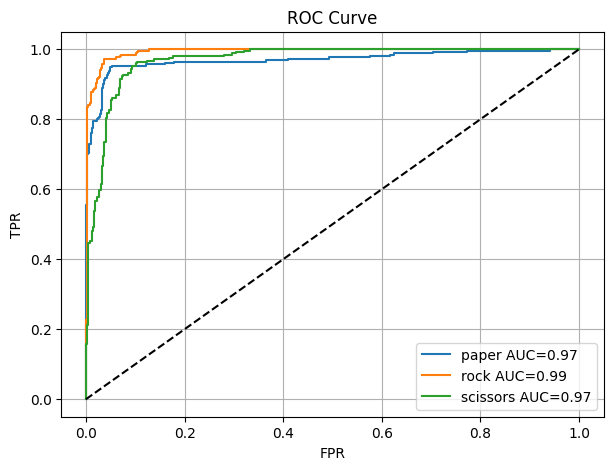

예측 결과 : scissors


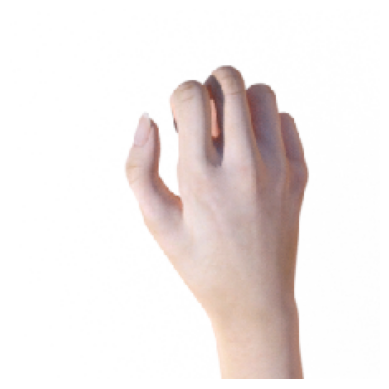

In [3]:
# Rock Paper Scissors 이미지 분류

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 데이터 다운로드
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/rps.zip
!unzip -q -o rps.zip

IMG_SIZE = (224, 224)
BATCH = 32

# 데이터셋 생성
train_ds = tf.keras.utils.image_dataset_from_directory(
    'rps',
    validation_split=0.3,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    'rps',
    validation_split=0.3,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names
print(class_names)

# 일부 출력
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels[:10].numpy())

# 증강 없는 모델
model1 = Sequential([
    Input(shape=(224,224,3)),
    Rescaling(1./255),

    Conv2D(32, 3, activation='relu'),
    MaxPooling2D(),

    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(patience=3, restore_best_weights=True)

history1 = model1.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[es]
)

# 증강 있는 모델
aug = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

model2 = Sequential([
    Input(shape=(224,224,3)),
    aug,
    Rescaling(1./255),

    Conv2D(32, 3, activation='relu'),
    MaxPooling2D(),

    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=[es]
)

# 성능 비교
loss1, acc1 = model1.evaluate(valid_ds, verbose=0)
loss2, acc2 = model2.evaluate(valid_ds, verbose=0)

print('증강 전 acc :', acc1)
print('증강 후 acc :', acc2)

# ROC Curve
y_true = []
y_score = []

for images, labels in valid_ds:
    pred = model2.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_score.extend(pred)

y_true = np.array(y_true)
y_score = np.array(y_score)

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(7,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_names[i]} AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# 새 이미지 예측
img_path = 'rps/rock/rock01-000.png'

img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = model2.predict(img_array, verbose=0)

print('예측 결과 :', class_names[np.argmax(pred)])

plt.imshow(img)
plt.axis('off')
plt.show()